Strategic Analysis of AI Adoption: Dynamics and Barriers in the EU (2021-2023)

This analysis investigates the trajectory of Artificial Intelligence (AI) adoption across European Union enterprises, with a specific focus on the structural disparities between Small and Medium Enterprises (SMEs) and Large Corporations. Based on Eurostat data from 2021 to 2023, the study identifies a persistent "Digital Divide" driven more by human capital shortages than by financial constraints. While some lagging nations show signs of "catching up" (beta-convergence), the internal gap within nations remains a critical policy challenge.

Using columns: Size -> 'size_emp', Indicator -> 'indic_is'
Filtering by: Indicator 'E_DI3_HI_AI_TANY' and Size '10-249'


C:\Users\Admin\AppData\Local\Temp\ipykernel_11228\1490583196.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reformers.index, y=top_reformers['delta'], palette='flare')


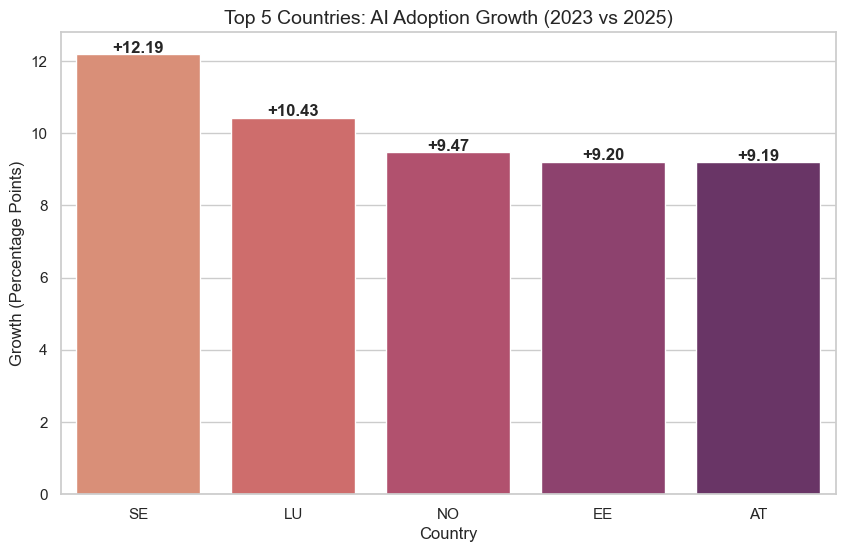

TIME_PERIOD,2023,2025,delta
geo,,,
SE,4.74,16.93,12.19
LU,5.61,16.04,10.43
NO,4.65,14.12,9.47
EE,2.26,11.46,9.20
AT,4.57,13.76,9.19


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("data/AI_adoption_in_EU_enterprises.csv")

# Smart search for required columns
# Finding the column responsible for size (usually 'size_emp' or similar)
size_col = [c for c in df.columns if 'size' in c.lower()][0]
# Finding the column with the indicator code (usually 'indic_is')
indic_col = [c for c in df.columns if 'indic' in c.lower()][0]

print(f"Using columns: Size -> '{size_col}', Indicator -> '{indic_col}'")

# Select the primary indicator (searching for the "Any AI" keyword)
# If 'E_AI_ANY' is not found, search for any indicator describing AI usage
if 'E_AI_ANY' in df[indic_col].unique():
    target_indicator = 'E_AI_ANY'
else:
    # Look for the indicator description column to find "any artificial intelligence"
    desc_col = [c for c in df.columns if 'indicator' in c.lower() and c != indic_col][0]
    mask = df[desc_col].str.contains('any artificial intelligence', case=False, na=False)
    target_indicator = df[mask][indic_col].unique()[0]

# Filter the data
# Selecting the general category (usually '10+' or 'All...')
size_value = [v for v in df[size_col].unique() if '10' in str(v)][0]

print(f"Filtering by: Indicator '{target_indicator}' and Size '{size_value}'")

growth_df = df[
    (df[size_col] == size_value) & 
    (df[indic_col] == target_indicator)
].copy()

# Create a Pivot Table
pivot = growth_df.pivot_table(index='geo', columns='TIME_PERIOD', values='OBS_VALUE')

# Check available years in the dataset
available_years = sorted(pivot.columns)

if len(available_years) < 2:
    print("Error: Only one year found or no data available.")
    print(f"Available years: {available_years}")
else:
    start_year = available_years[0]
    end_year = available_years[-1]
    
    # Calculate the Delta (growth)
    pivot['delta'] = pivot[end_year] - pivot[start_year]
    pivot = pivot.dropna(subset=['delta'])
    
    # Sort and select Top 5 "reformers" (fastest growing countries)
    # Note: You can manually drop 'EU27_2020' if it appears in your Top 5
    top_reformers = pivot.sort_values(by='delta', ascending=False).head(5)

    # Visualization
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_reformers.index, y=top_reformers['delta'], palette='flare')
    plt.title(f'Top 5 Countries: AI Adoption Growth ({start_year} vs {end_year})', fontsize=14)
    plt.ylabel('Growth (Percentage Points)')
    plt.xlabel('Country')
    
    # Add data labels on top of the bars
    for i, v in enumerate(top_reformers['delta']):
        plt.text(i, v + 0.05, f"+{v:.2f}", ha='center', fontweight='bold')
    
    plt.show()
    
    # Display the final results table
    display(top_reformers[[start_year, end_year, 'delta']])

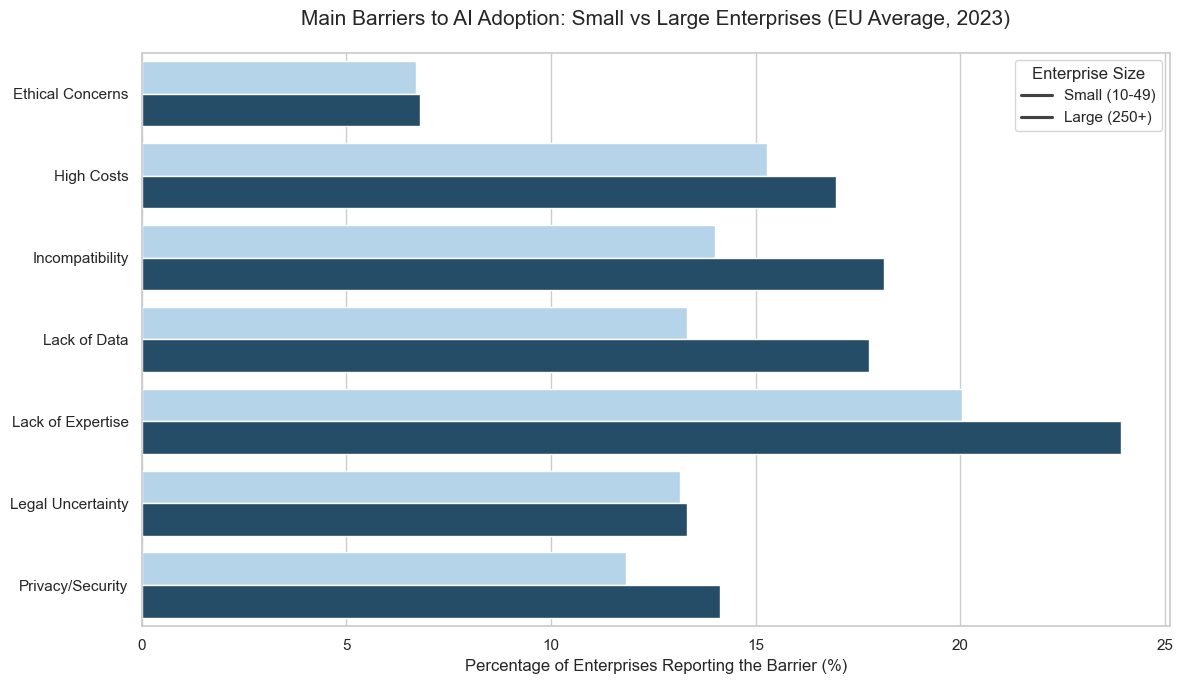

Top Barriers for Small Enterprises:
              Barrier  OBS_VALUE
8   Lack of Expertise  20.024891
2          High Costs  15.267717
4     Incompatibility  14.011522
6        Lack of Data  13.311630
10  Legal Uncertainty  13.145978
12   Privacy/Security  11.836304
0    Ethical Concerns   6.704457


In [25]:
# Define the list of Barriers from your CSV
barriers_map = {
    'E_AI_BCST': 'High Costs',
    'E_AI_BDDT': 'Lack of Data',
    'E_AI_BLE': 'Lack of Expertise',
    'E_AI_BINC': 'Incompatibility',
    'E_AI_BCDP': 'Privacy/Security',
    'E_AI_BLEG': 'Legal Uncertainty',
    'E_AI_BEC': 'Ethical Concerns'
}

# Filter for 2023 and compare Small (10-49) vs Large (GE250)
barriers_df = df[
    (df['indic_is'].isin(barriers_map.keys())) & 
    (df['TIME_PERIOD'] == 2023) & 
    (df['size_emp'].isin(['10-49', 'GE250']))
].copy()

barriers_df['Barrier'] = barriers_df['indic_is'].map(barriers_map)

# Calculate EU Average for each barrier
avg_barriers = barriers_df.groupby(['Barrier', 'size_emp'])['OBS_VALUE'].mean().reset_index()

# Visualization
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Create plot
sns.barplot(
    data=avg_barriers, 
    x='OBS_VALUE', 
    y='Barrier', 
    hue='size_emp', 
    palette=['#AED6F1', '#1B4F72'] # Light for Small, Dark for Large
)

# Formatting
plt.title('Main Barriers to AI Adoption: Small vs Large Enterprises (EU Average, 2023)', fontsize=15, pad=20)
plt.xlabel('Percentage of Enterprises Reporting the Barrier (%)', fontsize=12)
plt.ylabel('', fontsize=12)
plt.legend(title='Enterprise Size', labels=['Small (10-49)', 'Large (250+)'])
plt.tight_layout()

plt.show()

# Print summary for the report
print("Top Barriers for Small Enterprises:")
small_only = avg_barriers[avg_barriers['size_emp']=='10-49'].sort_values('OBS_VALUE', ascending=False)
print(small_only[['Barrier', 'OBS_VALUE']])

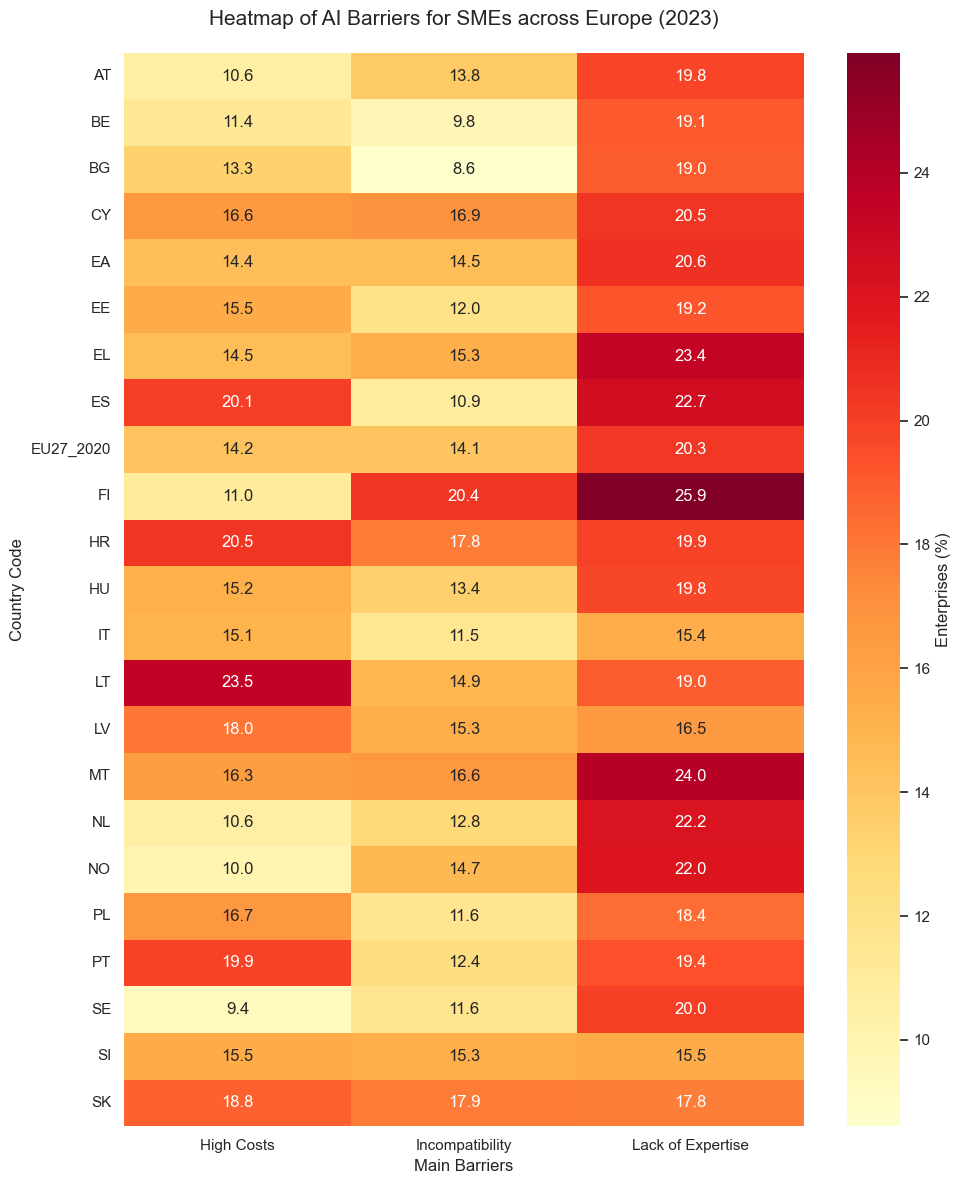

--- DEEP DIVE INSIGHTS ---
The barrier 'High Costs' is most critical in LT (23.474999999999998%)
The barrier 'Incompatibility' is most critical in FI (20.4475%)
The barrier 'Lack of Expertise' is most critical in FI (25.937500000000004%)


In [26]:
# Focus on the Top 3 barriers found in your previous plot
top_barriers = {
    'E_AI_BLE': 'Lack of Expertise',
    'E_AI_BCST': 'High Costs',
    'E_AI_BINC': 'Incompatibility'
}

# Filter data for Small Enterprises (10-49) in 2023
country_barriers = df[
    (df['indic_is'].isin(top_barriers.keys())) & 
    (df['TIME_PERIOD'] == 2023) & 
    (df['size_emp'] == '10-49')
].copy()

country_barriers['Barrier'] = country_barriers['indic_is'].map(top_barriers)

# Create Pivot Table (Countries vs Barriers)
heatmap_data = country_barriers.pivot_table(index='geo', columns='Barrier', values='OBS_VALUE')

# Drop countries with many missing values to keep it clean
heatmap_data = heatmap_data.dropna(thresh=2)

# Visualization: Heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(heatmap_data, annot=True, cmap="YlOrRd", fmt=".1f", cbar_kws={'label': 'Enterprises (%)'})

plt.title('Heatmap of AI Barriers for SMEs across Europe (2023)', fontsize=15, pad=20)
plt.xlabel('Main Barriers', fontsize=12)
plt.ylabel('Country Code', fontsize=12)
plt.tight_layout()

plt.show()

# Final Insight Generation
print("--- DEEP DIVE INSIGHTS ---")
for barrier in heatmap_data.columns:
    top_country = heatmap_data[barrier].idxmax()
    top_val = heatmap_data[barrier].max()
    print(f"The barrier '{barrier}' is most critical in {top_country} ({top_val}%)")

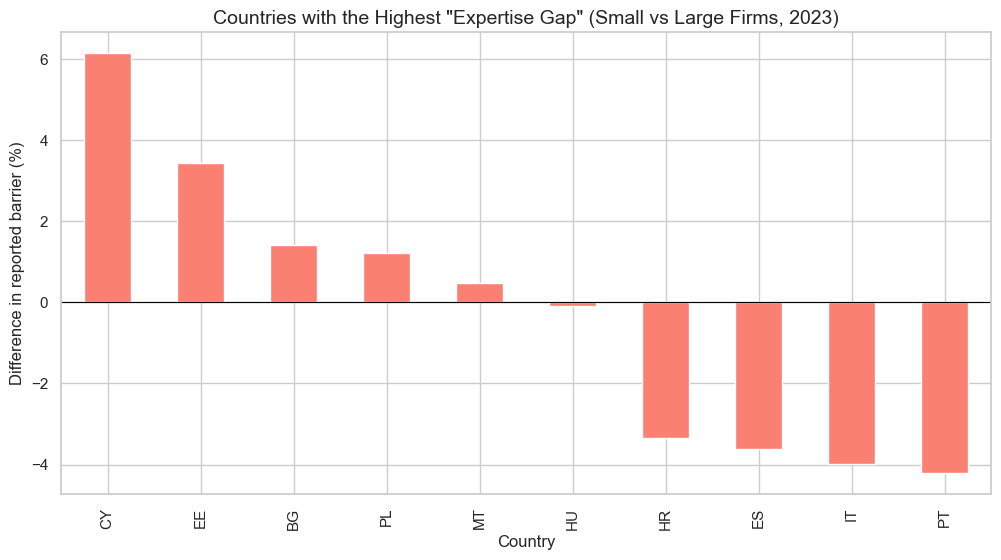

Top 3 Countries where SMEs suffer most from Knowledge Gaps compared to Large firms:
['CY', 'EE', 'BG']


In [27]:
# Focus on the Top 3 barriers identified in plot
target_barriers = {
    'E_AI_BLE': 'Lack of Expertise',
    'E_AI_BCST': 'High Costs',
    'E_AI_BINC': 'Incompatibility'
}

# Filter data for 2023
gap_analysis = df[
    (df['indic_is'].isin(target_barriers.keys())) & 
    (df['TIME_PERIOD'] == 2023) & 
    (df['size_emp'].isin(['10-49', 'GE250']))
].copy()

gap_analysis['Barrier'] = gap_analysis['indic_is'].map(target_barriers)

# Pivot and calculate the "Inequality Gap" (Large - Small)
gap_pivot = gap_analysis.pivot_table(
    index='geo', 
    columns=['Barrier', 'size_emp'], 
    values='OBS_VALUE'
)

# Calculate specific gaps for Expertise and Costs
# (We want to see where the Small firms are struggling much more than Large ones)
# Note: For barriers, a higher value is BAD.
gaps = pd.DataFrame(index=gap_pivot.index)
for b_name in target_barriers.values():
    gaps[f'{b_name}_Gap'] = gap_pivot[(b_name, '10-49')] - gap_pivot[(b_name, 'GE250')]

# Visualization: The "Crisis Map"
# Let's show countries where the gap in "Lack of Expertise" is highest
top_gaps = gaps.sort_values('Lack of Expertise_Gap', ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_gaps['Lack of Expertise_Gap'].plot(kind='bar', color='salmon')

plt.title('Countries with the Highest "Expertise Gap" (Small vs Large Firms, 2023)', fontsize=14)
plt.ylabel('Difference in reported barrier (%)')
plt.xlabel('Country')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

# Summary for the report
print("Top 3 Countries where SMEs suffer most from Knowledge Gaps compared to Large firms:")
print(top_gaps.index[:3].tolist())